In [ ]:
import h5py, numpy as np, matplotlib.pyplot as plt
filename = "nn_dineutron_spectrum.h5"
L = 48
by_Psq = {}

with h5py.File(filename, "r") as f:
    mN = f["mN/E0"][()]
    for gname, g in f.items():
        if gname == "mN":
            continue
        q1 = g["Psq_N1"][()][0]
        q2 = g["Psq_N2"][()][0]
        by_Psq.setdefault(q1, []).append(g["E_N1"][()])
        by_Psq.setdefault(q2, []).append(g["E_N2"][()])

Psq = np.array(sorted(by_Psq))
p2 = (2*np.pi/L)**2 * Psq
E = np.array([np.mean(by_Psq[q], axis=0) for q in Psq])
print(Psq)
print(p2)
print(E.shape)

[0 1 2 3 4]
[0.         0.01713473 0.03426946 0.05140419 0.06853892]
(5, 5001)


In [43]:
import h5py
import numpy as np
import matplotlib.pyplot as plt
import re

rng = np.random.default_rng(1234)

filename = "nn_dineutron_spectrum.h5"
L = 48.0
 
punit = 2*np.pi/L
punit2 = punit**2


def boot_err(x):
    return np.std(x[1:], ddof=1)


def get_dE(g):
    for key in ["dE_NN", "dE", "DeltaE", "E0", "dE0"]:
        if key in g:
            return np.array(g[key])
    raise KeyError(f"No energy shift found. Keys are {list(g.keys())}")


def get_irrep(name):
    return name.split("_Psq")[0]


def get_Psq_total(name):
    m = re.search(r"Psq(\d+)", name)
    if m is None:
        raise ValueError(f"Could not read total Psq from {name}")
    return int(m.group(1))


def get_level(name):
    m = re.search(r"level(\d+)", name)
    return int(m.group(1)) if m is not None else 0


def dvec_from_d2(d2):
    nmax = int(np.ceil(np.sqrt(max(d2, 1)))) + 2
    best = None
    for nx in range(nmax + 1):
        for ny in range(nmax + 1):
            for nz in range(nmax + 1):
                v = np.array([nx, ny, nz], dtype=int)
                if int(np.dot(v, v)) == int(d2):
                    cand = tuple(sorted(v))
                    if best is None or cand < best:
                        best = cand
    if best is None:
        raise ValueError(f"No integer momentum representative found for Psq={d2}")
    return np.array(best, dtype=int)


raw_levels = []

with h5py.File(filename, "r") as f:
    mN = np.array(f["mN/E0"])
    m = float(mN[0])

    for name, g in f.items():
        if name == "mN":
            continue

        irrep = get_irrep(name)
        Psq_tot = get_Psq_total(name)
        level_index = get_level(name)

        N1 = int(np.array(g["Psq_N1"])[0])
        N2 = int(np.array(g["Psq_N2"])[0])
        dE = get_dE(g)

        E1 = np.sqrt(mN**2 + punit2*N1)
        E2 = np.sqrt(mN**2 + punit2*N2)
        E_NN = dE + E1 + E2

        E_cm = np.sqrt(E_NN**2 - punit2*Psq_tot)
        kstar2 = E_cm**2/4 - mN**2
        q2 = kstar2/punit2

        raw_levels.append({
            "name": name,
            "irrep": irrep,
            "Psq_tot": Psq_tot,
            "level_index": level_index,
            "pair": tuple(sorted((N1, N2))),
            "Ecm_boot": E_cm,
            "q2_boot": q2,
        })

raw_levels = sorted(raw_levels, key=lambda r: (r["Psq_tot"], r["irrep"], r["level_index"], r["name"]))


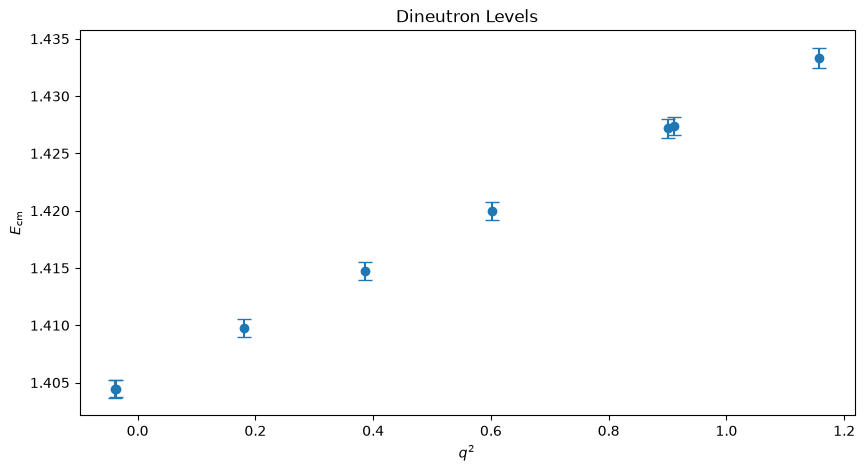

In [44]:
stdDevList = [boot_err(r["Ecm_boot"]) for r in raw_levels]

x = [r["q2_boot"][0] for r in raw_levels]
y = [r["Ecm_boot"][0] for r in raw_levels]


plt.figure(figsize=(10,5))
plt.errorbar(x, y, yerr=stdDevList, fmt='o', capsize=5)
plt.xlabel(r"$q^2$")
plt.ylabel(r"$E_{\rm cm}$")
plt.title("Dineutron Levels")
plt.show()

In [54]:
import itertools
from scipy import special as sp

xi = 0.5
#m = 1.0
nMax = 10
alpha = 0.125
eps = 1e-16

alpha_dim = (L/(2*np.pi))**2 * alpha

def E_cm(E,P):
    return np.sqrt(E**2 - np.dot(P,P))


def Q_cm(Ecm):
    return 0.5 * np.sqrt( Ecm**2 - 4.0 * m**2 +eps*1j)
    #return 0.5*np.sqrt(Ecm**2 - 4*m**2 + 0j)

def Rho(Ecm):
    return xi * Q_cm(Ecm) / ( 8.0 * np.pi * np.sqrt(Ecm**2) )

def lorentzBoost(E,P,k):
    if np.allclose(P, 0):
        return k
    gamma = E / E_cm(E,P)
    beta = P / E
    kParallel = np.dot(k,P) / np.dot(P,P) * P
    kPerp = k - kParallel
    omega = np.sqrt(np.dot(k,k) + m**2)
    kParallelBoosted =  gamma * (kParallel - beta * omega)
    return kParallelBoosted + kPerp 

def Sigma(E,P,L):
    total = 0
    qStar = Q_cm(E_cm(E,P))
    intCombinations = np.array(np.arange(-nMax,nMax+1,1))
    for i in itertools.product(intCombinations, repeat = 3):
        nConstant = np.array(i)
        k = (2.0 * np.pi / L) * nConstant
        k2 = np.dot(k,k)
        kStar = lorentzBoost(E,P,k)

        omega = np.sqrt(np.dot(k,k) + m**2)
        omegaStar = np.sqrt(np.dot(kStar,kStar) + m**2)

        firstTerm = omegaStar / omega 
        secondTerm = np.exp(-alpha_dim*(np.dot(kStar,kStar) - qStar**2)) / (qStar**2 - np.dot(kStar,kStar))

        total += firstTerm * secondTerm
    return total

def part2(E,P):
    qStar = Q_cm(E_cm(E,P))
    term1 = xi / (4*np.pi**2*E_cm(E,P))
    term2 = np.sqrt(np.pi/(4*alpha_dim)) * np.exp(alpha_dim*qStar**2)
    term3 = sp.erfi(np.sqrt(alpha_dim) * qStar) * np.pi*qStar/2
    return term1 * (term2 - term3)

def Fpv(E, P, L):
    term1 =  xi * Sigma(E,P,L) / (L**3 * 2* E_cm(E,P)) 
    term2 = part2(E,P)
    return term1 + term2

def F(E, P, L):
    term1 = 1j * Rho(E_cm(E,P)) + xi * Sigma(E,P,L) / (L**3 * 2* E_cm(E,P)) 
    term2 = part2(E,P)
    return term1 + term2



In [3]:
print(type(F))

<class 'function'>


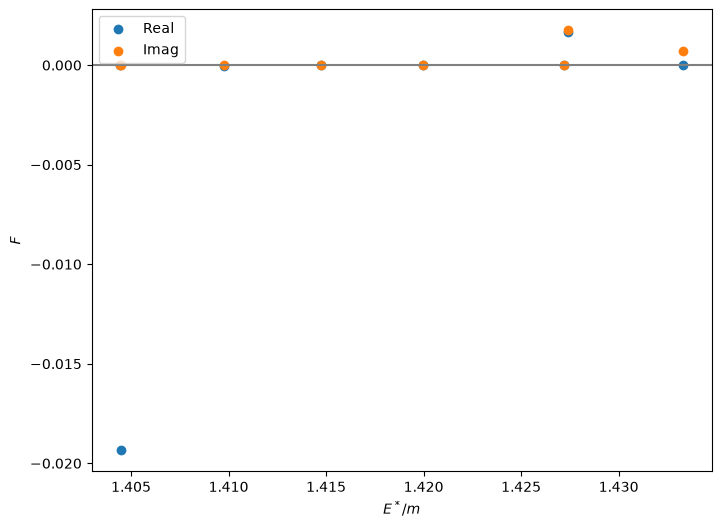

In [55]:
E_values = []
F_real = []
F_imag = []

for level in raw_levels:

    Ecm = level["Ecm_boot"][0]

    P = dvec_from_d2(level["Psq_tot"])* (2*np.pi/L)

    value = F(Ecm, P, L)

    E_values.append(Ecm)

    F_real.append(np.real(value))
    F_imag.append(np.imag(value))

plt.figure(figsize=(8,6))

plt.scatter(E_values, F_real, label="Real")
plt.scatter(E_values, F_imag, label="Imag")

plt.axhline(0,color="gray")

plt.xlabel(r"$E^*/m$")
plt.ylabel(r"$F$")

plt.legend()

plt.show()

In [56]:
M_values = []
qcot_values = []
q2_values = []

for level in raw_levels:

    # Central bootstrap values
    Ecm = float(level["Ecm_boot"][0])
    q2 = level["q2_boot"][0]



    # Total momentum vector
    P = dvec_from_d2(level["Psq_tot"]) * (2*np.pi/L)

    E_lab = np.sqrt(Ecm**2 + np.dot(P,P))

    # Finite-volume function
    Fvalue = F(E_lab, P, L)

    # Phase-space factor
    rho = Rho(Ecm)

    # Scattering amplitude
    M = 1 / (-Fvalue+ eps*1j)

    # q (allow complex values for bound states)
    q = np.sqrt(q2 + eps*1j)

    # q cot(delta)
    qcot = np.real(8*np.pi*Ecm / M)

    # Store results
    q2_values.append(q2)
    M_values.append(M)
    qcot_values.append(qcot)

print(Ecm)
print(q2_values)
print(L)
print(M_values)

1.4271811314910883
[np.float64(-0.03629042122754882), np.float64(0.9101829638601577), np.float64(0.18138517939317653), np.float64(1.157891032073938), np.float64(0.3858152818330002), np.float64(0.6022474173188834), np.float64(-0.03866938376980722), np.float64(0.9015908533569345)]
24
[np.complex128(51.658801566396804-2.4725865397144793e-12j), np.complex128(-286.9801716670628+299.9923649840098j), np.complex128(87.72814516371426+1265.0231963213528j), np.complex128(-110.04107207955225+24.884465431705763j), np.complex128(-178.6670882766246+836.4554429282381j), np.complex128(-102.8457945459934+687.2354052280776j), np.complex128(59.14608634009717-2.733317600277914e-12j), np.complex128(-287.1797409770663+317.0431481621377j)]


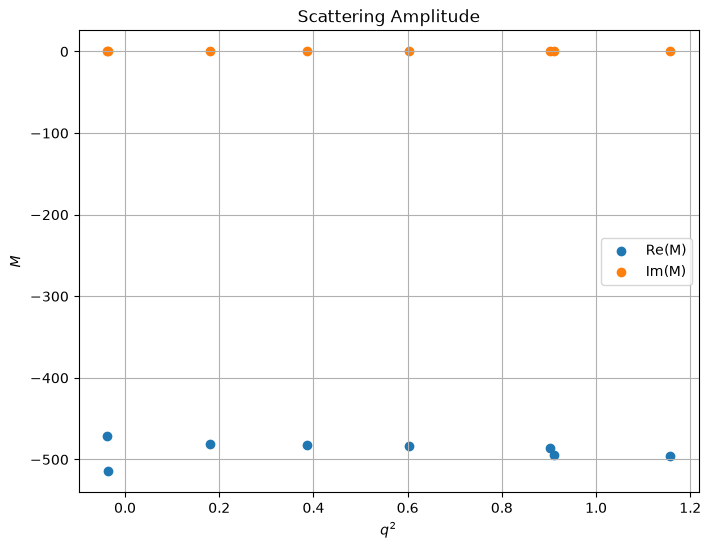

In [39]:
plt.figure(figsize=(8,6))

plt.scatter(q2_values,
            np.real(M_values),
            label="Re(M)")

plt.scatter(q2_values,
            np.imag(M_values),
            label="Im(M)")

plt.xlabel(r"$q^2$")
plt.ylabel(r"$M$")
plt.title("Scattering Amplitude")
plt.legend()

plt.grid(True)

plt.show()



Text(0.5, 1.0, 'Imaginary part of M vs q^2')

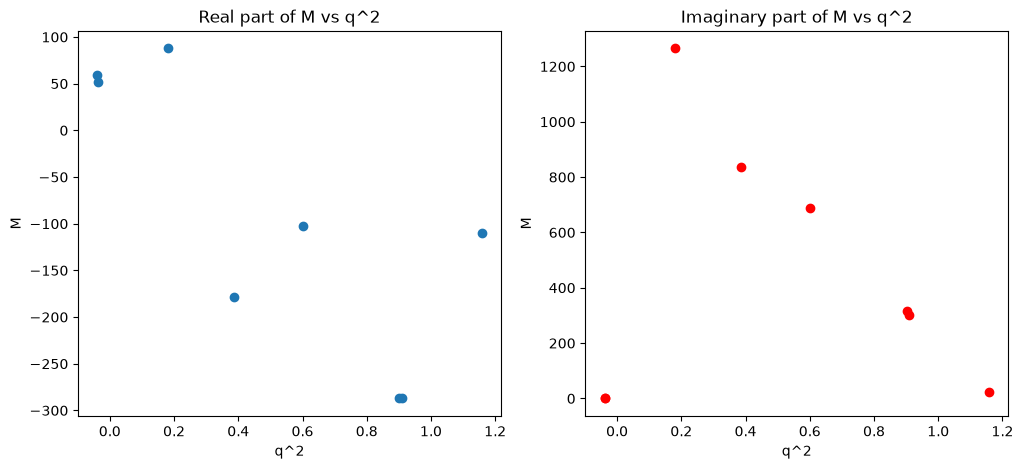

In [57]:

plt.figure(figsize=(12, 5))
ax1 = plt.gcf().add_subplot(121)
ax2 = plt.gcf().add_subplot(122)

ax1.scatter(q2_values, np.real(M_values), label="Real part of M")
ax1.set_xlabel("q^2")
ax1.set_ylabel("M")
ax1.set_title("Real part of M vs q^2")

ax2.scatter(q2_values, np.imag(M_values), label="Imaginary part of M", color = 'red')
ax2.set_xlabel("q^2")
ax2.set_ylabel("M")
ax2.set_title("Imaginary part of M vs q^2")

45


KeyboardInterrupt: 

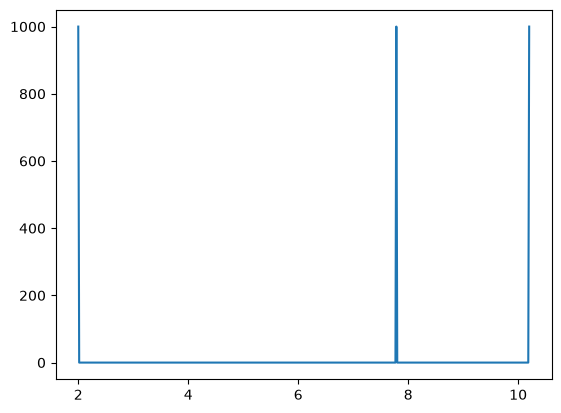

In [58]:
import numpy as np
import matplotlib.pyplot as plt

M = 0.0696
L = 24

d = np.array([0, 0, 0])
punit = 2 * np.pi / L
Pvec = punit * d
P2 = np.dot(Pvec, Pvec)

E_min = 2 * M
E_max = 10 * M

levels = []

E_grid = np.linspace(2 * M, 10.2 * M, 500)
Farray = np.zeros_like(E_grid)

for i in range(-5, 6):
    for j in range(-5, 6):
        for k in range(-5, 6):

            n1 = np.array([i, j, k])
            n2 = d - n1

            p1 = punit * n1
            p2 = punit * n2

            E_lab = (np.sqrt(np.dot(p1, p1) + M**2) +
                     np.sqrt(np.dot(p2, p2) + M**2))
           
            E_star = np.sqrt(E_lab**2 - P2)
            levels.append(E_star)

levels = np.unique(np.round(levels, 12))

for E_star in levels:
    idx = np.argmin(np.abs(E_grid - E_star))
    Farray[idx] = 1000 #np.inf

print(len(levels))

plt.plot(E_grid / M, Farray)

F_values = []
for i in range(len(E_grid)):
    F_values.append(F(E_grid[i], 0, L))
plt.plot(E_grid / M, F_values)
plt.xlim(1.9, 10.1)
plt.show()

print(F(1,0,L))

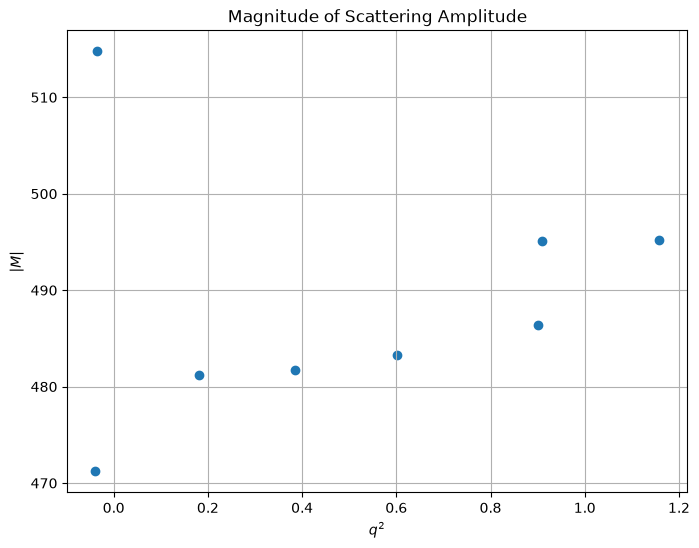

In [41]:
plt.figure(figsize=(8,6))

plt.scatter(q2_values,
            np.abs(M_values))

plt.xlabel(r"$q^2$")
plt.ylabel(r"$|M|$")
plt.title("Magnitude of Scattering Amplitude")

plt.grid(True)

plt.show()

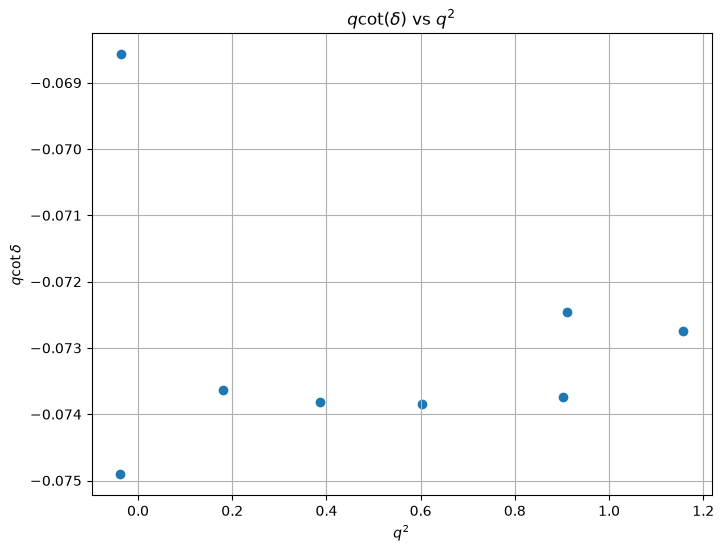

In [42]:
plt.figure(figsize=(8,6))

plt.scatter(q2_values,
            qcot_values)

plt.xlabel(r"$q^2$")
plt.ylabel(r"$q\cot\delta$")
plt.title(r"$q\cot(\delta)$ vs $q^2$")

plt.grid(True)

plt.show()

In [ ]:
# import re

# Psq = []

# filename = "nn_dineutron_spectrum.h5"

# with h5py.File(filename, "r") as f:
#     for name in f.keys():
#         Psq.append(int(re.match(r"(\d+)", name).group(1)))